# SSM-2 aside — the parallel scan

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm2-aside-parallel-scan.ipynb)

*A companion to [SSM-2](ssm2-selectivity.ipynb): selectivity makes the recurrence time-varying, so it is no longer a convolution. This shows how you still run it in parallel instead of a left-to-right loop, in $O(\log T)$ depth. Optional: read it when SSM-2 §3 points here.*

> Grounding: [S5](https://arxiv.org/abs/2208.04933) (Smith et al., 2022) computes the linear SSM recurrence with an associative parallel scan in place of S4's convolution; [Mamba](https://arxiv.org/abs/2312.00752) (Gu & Dao, 2023) §3.3 runs the same scan inside a hardware-aware kernel. The canonical reference for the work-efficient associative scan is Blelloch's "Prefix sums and their applications" ([Blelloch, 1990](https://www.cs.cmu.edu/~guyb/papers/Ble93.pdf)).

## 1. The recurrence as a chain of affine maps

SSM-2 made the step size and the input and output maps depend on the token, so $\bar A_t$ and $\bar B_t$ change at every position and the single convolution kernel of SSM-1 is gone. What is left is the bare recurrence $h_t=\bar A_t h_{t-1}+\bar B_t x_t$, and the obvious way to run it is a left-to-right loop that carries the state one token at a time. That loop is $T$ steps deep: each state waits on the one before it, so a sequence of length $T$ takes $T$ sequential stages no matter how many processors you have.

The way out starts with a small observation. Each step is an affine map of the state: step $t$ sends $h$ to $\bar A_t h+\bar B_t x_t$, and once $x_t$ is known that map is fixed, with no further dependence on $h$. Write the map as a pair $(a_t,b_t)$ with $a_t=\bar A_t$ and $b_t=\bar B_t x_t$, standing for $h\mapsto a_t h+b_t$. Running the recurrence from $h_0$ to $h_t$ is then applying these maps in order, $f_t\circ f_{t-1}\circ\cdots\circ f_1$.

Composing two consecutive maps gives another affine map. Apply $f_{t-1}$ then $f_t$:

$$h\;\mapsto\;a_t\big(a_{t-1}h+b_{t-1}\big)+b_t\;=\;\big(a_t a_{t-1}\big)h+\big(a_t b_{t-1}+b_t\big).$$

The result is again of the form $h\mapsto a\,h+b$, so it has its own pair. Define the combine operator that produces that pair from an earlier map $(a_1,b_1)$ and a later map $(a_2,b_2)$:

$$(a_1,b_1)\bullet(a_2,b_2)=\big(a_1 a_2,\ a_2 b_1+b_2\big).$$

Reading left to right, $u\bullet v$ means "apply $u$, then $v$". Because $\bullet$ is composition of affine maps, it inherits associativity: $(u\bullet v)\bullet w$ and $u\bullet(v\bullet w)$ are the same composed map. Function composition is always associative, but the payoff here is that we can check it on the pairs by pure algebra, and that associativity is the single property a parallel scan needs. The cell builds the pairs from a small selective recurrence and verifies it as an exact identity.

In [1]:
import torch

torch.manual_seed(0)

# A small time-varying (selective) recurrence: h_t = Abar_t h_{t-1} + Bbar_t x_t.
# After SSM-2's selectivity Abar_t, Bbar_t change every step, so there is no single
# convolution kernel, only this per-step recurrence. Scalar state (N=1) keeps it legible.
T = 8
A = torch.tensor(-1.0)
x = torch.randn(T)
delta = torch.rand(T) * 2.0 + 0.1          # a different step size per token (selectivity)
Abar = torch.exp(delta * A)                # a_t = exp(delta_t A): now varies with t
Bbar = (Abar - 1.0) / A                    # diagonal ZOH input weight (Mamba Eq. 4)
b = Bbar * x                               # b_t = Bbar_t x_t

# Each step is the affine map  h -> a_t h + b_t, carried as the pair (a_t, b_t).
pairs = list(zip(Abar.tolist(), b.tolist()))

def combine(u, v):
    # u is the earlier map, v the later one: "do u, then v".
    # (a1,b1) . (a2,b2) = (a1 a2, a2 b1 + b2), the composition of two affine maps.
    (a1, b1), (a2, b2) = u, v
    return (a1 * a2, a2 * b1 + b2)

# Associativity is the whole trick: combine(combine(u,v),w) == combine(u,combine(v,w)).
u, v, w = pairs[0], pairs[1], pairs[2]
left  = combine(combine(u, v), w)
right = combine(u, combine(v, w))
print("combine(combine(u,v),w) =", tuple(round(z, 6) for z in left))
print("combine(u,combine(v,w)) =", tuple(round(z, 6) for z in right))
assert torch.allclose(torch.tensor(left), torch.tensor(right), atol=1e-6)
print("assert passes: the combine operator is associative")

# The pair really is the composition: applying it to a state h equals doing u then v.
h0 = 0.37
a12, b12 = combine(u, v)
applied_in_order = v[0] * (u[0] * h0 + u[1]) + v[1]
print(f"\ncomposed pair on h={h0}: {a12 * h0 + b12:.6f}   apply u then v: {applied_in_order:.6f}")
assert abs((a12 * h0 + b12) - applied_in_order) < 1e-6
print("assert passes: (a,b) composes the two affine maps")

combine(combine(u,v),w) = (0.026852, -0.764215)
combine(u,combine(v,w)) = (0.026852, -0.764215)
assert passes: the combine operator is associative

composed pair on h=0.37: -0.006272   apply u then v: -0.006272
assert passes: (a,b) composes the two affine maps


Both groupings return the identical pair, so $\bullet$ is associative to floating-point tolerance, and the composed pair applied to a state matches running the two maps one after the other. That second check confirms the pair is not a bookkeeping trick but the actual composition. Associativity is what lets a scan regroup the long chain $f_T\circ\cdots\circ f_1$ into a balanced tree of combines and evaluate it in $O(\log T)$ depth, which is the next section.

## 2. Sequential scan versus log-depth parallel scan

A prefix scan over $\bullet$ produces, at each position $t$, the running composition $P_t=(\bar A_1,\bar B_1 x_1)\bullet\cdots\bullet(\bar A_t,\bar B_t x_t)$, which is the affine map from $h_0$ to $h_t$. With $h_0=0$ the $a$-component multiplies zero and drops out, so the $b$-component of $P_t$ is exactly $h_t$. One scan over the pairs therefore returns the whole state trajectory.

The direct way to compute the scan is left to right: fold $\bullet$ across the sequence, one combine per token. This is the loop again, $T-1$ combines stacked in a chain of depth $T-1$, each waiting on the previous result. Associativity buys a different schedule. Since regrouping is free, the same prefixes can be assembled by a balanced tree of combines. The Hillis–Steele scan is the plainest version: at pass $d$ every position $i$ combines itself with the position $2^d$ back, $x_i\leftarrow x_{i-2^d}\bullet x_i$, and after $\lceil\log_2 T\rceil$ passes each position holds its full prefix. The passes run in sequence, but the combines inside a pass are independent, so the dependency depth is $O(\log T)$ rather than $O(T)$.

The two scans compute the same prefixes with the operator only reassociated, so their outputs must agree exactly, and the $b$-components must match the state from the plain recurrence. The cell asserts both, prints the depth each scan reaches, and sweeps $T$ to show the depths growing as $T$ against $\log T$. One caveat rides along: Hillis–Steele reaches log depth by doing more total combines than the loop, $O(T\log T)$ against $O(T)$. It trades work for depth. Blelloch's work-efficient scan recovers $O(\log T)$ depth at $O(T)$ work, and that is the version real SSM kernels build on.

max |sequential - parallel| over prefixes = 0.00e+00
assert passes: sequential and parallel scans agree exactly
max |scan b-component - recurrence h_t| = 0.00e+00
assert passes: the scan reproduces the recurrence's state trajectory

T = 8
  sequential loop : depth  7   (7 combines)   O(T) depth
  parallel scan   : depth  3   (17 combines)   O(log T) depth, more total work


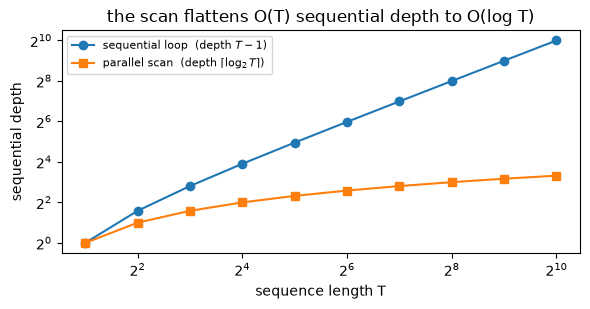

at T=1024 the loop is 1023 stages deep; the scan is 10.


In [2]:
import math
import matplotlib.pyplot as plt

def recurrence(Abar, Bbar_x):
    # the plain left-to-right loop: h_t = a_t h_{t-1} + b_t, with h_0 = 0
    h, hs = 0.0, []
    for a, bt in zip(Abar.tolist(), Bbar_x.tolist()):
        h = a * h + bt
        hs.append(h)
    return torch.tensor(hs)

def sequential_scan(pairs, combine):
    # fold . left to right: one combine per step, dependency depth = T - 1
    out, ops = [pairs[0]], 0
    for i in range(1, len(pairs)):
        out.append(combine(out[-1], pairs[i]))
        ops += 1
    return out, len(pairs) - 1, ops

def parallel_scan(pairs, combine):
    # Hillis-Steele inclusive scan. Pass d combines each position with the one 2^d back;
    # combines within a pass are independent, so depth = ceil(log2 T).
    cur = list(pairs)
    depth, ops, offset = 0, 0, 1
    while offset < len(pairs):
        nxt = list(cur)
        for i in range(offset, len(pairs)):
            nxt[i] = combine(cur[i - offset], cur[i])
            ops += 1
        cur, offset, depth = nxt, offset * 2, depth + 1
    return cur, depth, ops

seq_pref, seq_depth, seq_ops = sequential_scan(pairs, combine)
par_pref, par_depth, par_ops = parallel_scan(pairs, combine)

# 1) the two scans return identical prefixes: same operator, only regrouped
seq_b = torch.tensor([p[1] for p in seq_pref])
par_b = torch.tensor([p[1] for p in par_pref])
print("max |sequential - parallel| over prefixes =", f"{(seq_b - par_b).abs().max().item():.2e}")
assert torch.allclose(seq_b, par_b, atol=1e-6)
print("assert passes: sequential and parallel scans agree exactly")

# 2) the b-component of the scan is the state h_t (h_0 = 0)
h_loop = recurrence(Abar, b)
print("max |scan b-component - recurrence h_t| =", f"{(par_b - h_loop).abs().max().item():.2e}")
assert torch.allclose(par_b, h_loop, atol=1e-6)
print("assert passes: the scan reproduces the recurrence's state trajectory")

print(f"\nT = {T}")
print(f"  sequential loop : depth {seq_depth:2d}   ({seq_ops} combines)   O(T) depth")
print(f"  parallel scan   : depth {par_depth:2d}   ({par_ops} combines)   O(log T) depth, more total work")

# depth versus sequence length: O(T) against O(log T)
Ts = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
seq_d = [t - 1 for t in Ts]
par_d = [math.ceil(math.log2(t)) for t in Ts]
plt.figure(figsize=(6, 3.2))
plt.plot(Ts, seq_d, "o-", label="sequential loop  (depth $T-1$)")
plt.plot(Ts, par_d, "s-", label=r"parallel scan  (depth $\lceil\log_2 T\rceil$)")
plt.xscale("log", base=2); plt.yscale("log", base=2)
plt.xlabel("sequence length T"); plt.ylabel("sequential depth")
plt.title("the scan flattens O(T) sequential depth to O(log T)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print("at T=1024 the loop is 1023 stages deep; the scan is 10.")

The sequential and parallel scans return the same prefixes, and the scan's $b$-components match the recurrence's $h_t$ to floating point, so the parallel schedule computes exactly the state SSM-2's loop computes. Only the depth differs: the loop stacks $T-1$ combines that each wait on the last, while the Hillis–Steele scan finishes in $\lceil\log_2 T\rceil$ passes, and the plot shows that gap widening from a few levels to hundreds as $T$ grows. The scan pays in total combines, $O(T\log T)$ here against the loop's $O(T)$, which a work-efficient scan removes. On real hardware the independent combines inside each pass run at once, so log-depth is what turns a length-$T$ recurrence into a parallel computation.

## What this shows

- **A time-varying linear recurrence is a chain of affine maps, and composing affine maps is associative.** Writing each step as a pair $(\bar A_t,\ \bar B_t x_t)$ and composing with $(a_1,b_1)\bullet(a_2,b_2)=(a_1a_2,\ a_2b_1+b_2)$ turns "run the recurrence" into "prefix-scan the pairs". Associativity is the property that makes it valid, and it holds exactly.
- **Associativity lets the scan choose its schedule.** The prefixes computed left to right in $O(T)$ sequential depth are also computed by a balanced tree in $O(\log T)$ depth. The sequential and parallel scans return identical outputs, and the scan's $b$-component is the state $h_t$ that SSM-2's loop produces.
- **This is why selectivity did not cost the parallel form.** SSM-1 trained by convolution; SSM-2 broke that convolution, but the selective recurrence is still associative, so a prefix scan recovers parallel evaluation. S5 computes linear SSMs this way, and Mamba's selective scan is the same idea wrapped in a hardware-aware kernel.

**Honest scope.** This is a plain Python and tensor scan, written to make associativity and depth visible; it makes no throughput claim. Hillis–Steele here runs $O(T\log T)$ combines against the loop's $O(T)$, so on one CPU thread the loop is faster at these sizes. The win is parallel *depth* on hardware that evaluates the independent combines together, and a work-efficient scan (Blelloch) closes the extra-work gap. The toy carries a scalar mode ($N=1$), so a pair is two numbers; a real selective SSM keeps $\bar A_t$ as a diagonal and the combine is the same formula with elementwise products. And the speed of the real thing comes from keeping that state in SRAM across the scan (Mamba §3.3), which a Python loop does not model. What the toy settles is the claim SSM-2 forwards here: the selective recurrence is associative, so it runs as a prefix scan in $O(\log T)$ depth instead of a $T$-step loop.